In [11]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [12]:
print(os.getcwd())
print(os.listdir("data/san_francisco"))

c:\Dev\projects
['san_1.bmp', 'san_2.bmp', 'san_gt.bmp']


In [6]:
img1 = cv2.imread("data/san_francisco/san_1.bmp", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("data/san_francisco/san_2.bmp", cv2.IMREAD_GRAYSCALE)
gt = cv2.imread("data/san_francisco/san_gt.bmp", cv2.IMREAD_GRAYSCALE)

print(img1.shape, img2.shape, gt.shape)

(256, 256) (256, 256) (256, 256)


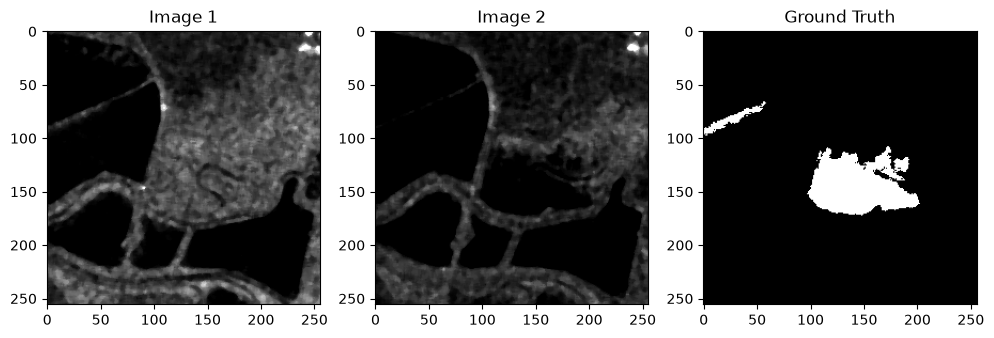

In [13]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img1, cmap='gray'); plt.title("Image 1")
plt.subplot(1, 3, 2); plt.imshow(img2, cmap='gray'); plt.title("Image 2")
plt.subplot(1, 3, 3); plt.imshow(gt, cmap='gray'); plt.title("Ground Truth")
plt.show()

San_1 and san_2 look nearly identical, but somewhere in there pixels have changed. We need to highlight where they changed. Simply subtracting one image from the other works for optical images, but SAR has speckle noise that makes subtraction messy.

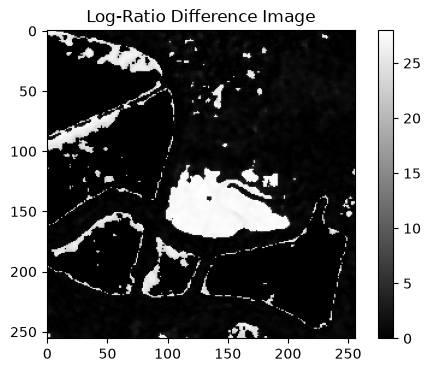

In [14]:
img1_float = img1.astype(np.float32) + 1e-10
img2_float = img2.astype(np.float32) + 1e-10
log_ratio = np.abs(np.log(img1_float)-np.log(img2_float))

plt.figure(figsize=(6, 4))
plt.imshow(log_ratio, cmap='gray')
plt.title("Log-Ratio Difference Image")
plt.colorbar()
plt.show()

The log-ratio image is a rough estimate of change it caught the real changed areas (matching gt) but also flagged extra patches that aren't actually changed. That's just SAR noise being picked up.
The CNN's job is to learn the difference between "this bright patch is real change" and "this bright patch is just noise." It does that by also looking at the surrounding context (the neighbourhood of pixels around each point), not just one pixel in isolation.